In [1]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
#importing cleaned data
filepath = r'C:/Users/venta/Documents/Grad Plans/portfolio/Quantium/QVI_data.csv'
df = pd.read_csv(filepath, header=0)
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Chip Compny SeaSalt,2,6.0,175.0,Natural,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,Nacho Cheese,3,6.3,175.0,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Crinkle Cut Chips Chicken,2,2.9,170.0,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Chip Thinly S/Cream&Onion,5,15.0,175.0,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Tortilla ChpsHny&Jlpno Chili,3,13.8,150.0,Kettle,MIDAGE SINGLES/COUPLES,Budget


In [3]:
#calculate total sales by LIFESTAGE and PREMIUM_CUSTOMER
sales_summary = df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()
sales_summary

,LIFESTAGE,PREMIUM_CUSTOMER,TOT_SALES
0,MIDAGE SINGLES/COUPLES,Budget,33345.70
1,MIDAGE SINGLES/COUPLES,Mainstream,84734.25
2,MIDAGE SINGLES/COUPLES,Premium,54443.85
3,NEW FAMILIES,Budget,20607.45
4,NEW FAMILIES,Mainstream,15979.70
5,NEW FAMILIES,Premium,10760.80
6,OLDER FAMILIES,Budget,156863.75
7,OLDER FAMILIES,Mainstream,96413.55
8,OLDER FAMILIES,Premium,75242.60
9,OLDER SINGLES/COUPLES,Budget,127833.60


Text(0, 0.5, 'Total Sales')

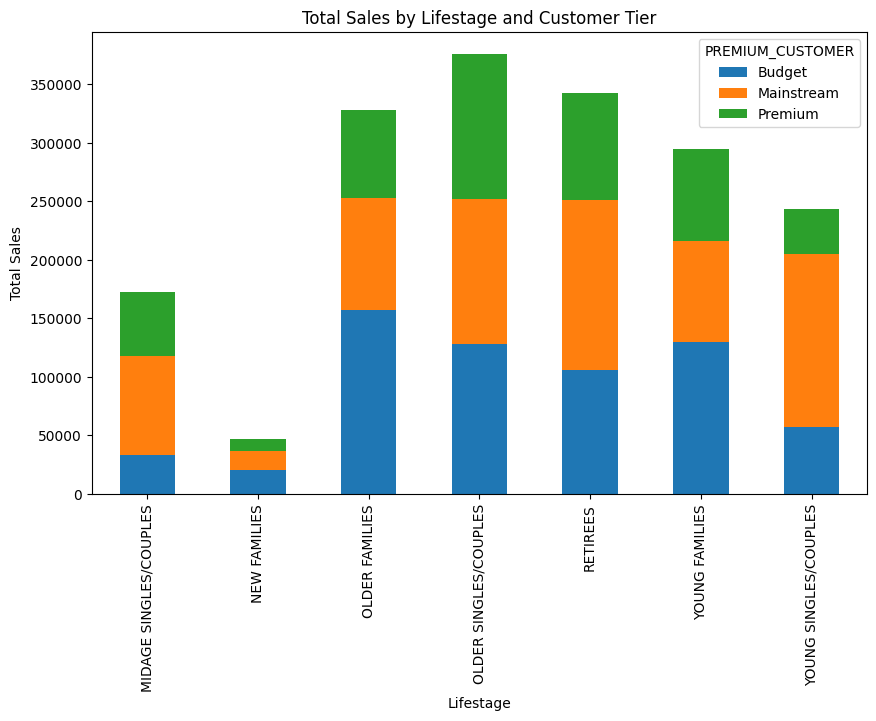

In [4]:
#creating a bar plot with a pivot table for customer categories
sales_summary.pivot(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', values='TOT_SALES').plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Total Sales by Lifestage and Customer Tier')
plt.xlabel('Lifestage')
plt.ylabel('Total Sales')

                 LIFESTAGE PREMIUM_CUSTOMER  LYLTY_CARD_NBR
0   MIDAGE SINGLES/COUPLES           Budget            1474
1   MIDAGE SINGLES/COUPLES       Mainstream            3298
2   MIDAGE SINGLES/COUPLES          Premium            2369
3             NEW FAMILIES           Budget            1087
4             NEW FAMILIES       Mainstream             830
5             NEW FAMILIES          Premium             575
6           OLDER FAMILIES           Budget            4611
7           OLDER FAMILIES       Mainstream            2788
8           OLDER FAMILIES          Premium            2231
9    OLDER SINGLES/COUPLES           Budget            4849
10   OLDER SINGLES/COUPLES       Mainstream            4858
11   OLDER SINGLES/COUPLES          Premium            4682
12                RETIREES           Budget            4385
13                RETIREES       Mainstream            6358
14                RETIREES          Premium            3812
15          YOUNG FAMILIES           Bud

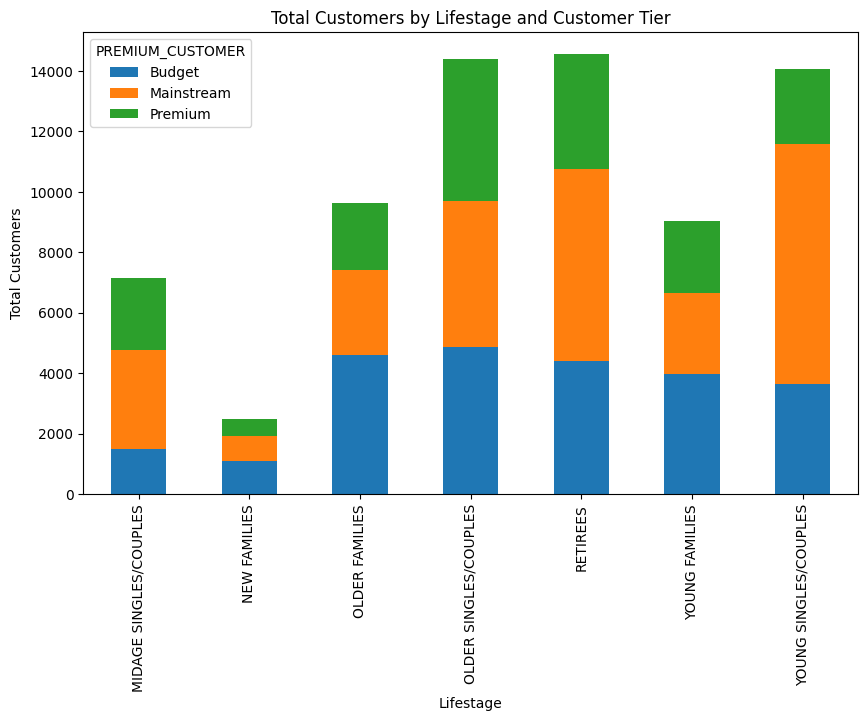

In [8]:
#calculate total customers by LIFESTAGE and PREMIUM_CUSTOMER
customer_counts = df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique().reset_index()
print(customer_counts)
#make pivot table for bar plot
customer_counts.pivot(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', values='LYLTY_CARD_NBR').plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Total Customers by Lifestage and Customer Tier')
plt.xlabel('Lifestage')
plt.ylabel('Total Customers')
customer_counts.to_csv('customer_counts.csv', index=False)

In [6]:
#there is a higher number of young singles/couples than they spend total, and more mainstream young singles/couples than mainstream older singles/couples
#check avg number of units per customer by lifestage and premium_customer

#numerator
total_quantity = df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['PROD_QTY'].sum().reset_index()
#merge
avg_qty = total_quantity.merge(customer_counts, on = ['LIFESTAGE','PREMIUM_CUSTOMER'])
#calculate in new column
avg_qty['AVG_QTY'] = avg_qty['PROD_QTY'] / avg_qty['LYLTY_CARD_NBR']

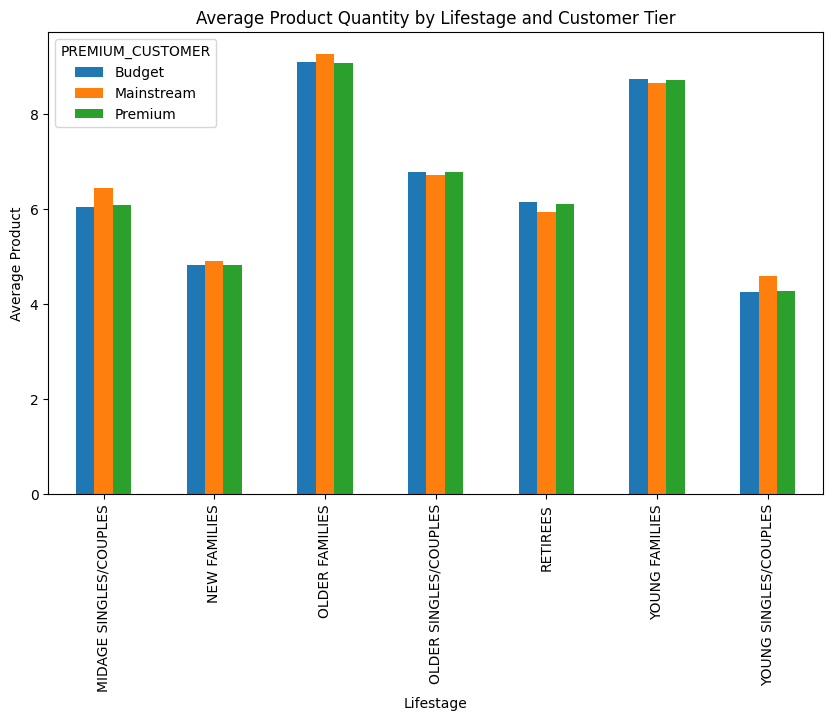

In [7]:
#make pivot table for bar plot
avg_qty.pivot(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', values='AVG_QTY').plot(kind='bar', stacked=False, figsize=(10,6))
plt.title('Average Product Quantity by Lifestage and Customer Tier')
plt.xlabel('Lifestage')
plt.ylabel('Average Product')
avg_qty.to_csv('avg_qty.csv', index=False)

In [9]:
#average price per unit by LIFESTAGE and PREMIUM_CUSTOMER
avg_qty = avg_qty.merge(sales_summary, on=['LIFESTAGE','PREMIUM_CUSTOMER'])
avg_qty.head()

,LIFESTAGE,PREMIUM_CUSTOMER,PROD_QTY,LYLTY_CARD_NBR,AVG_QTY,TOT_SALES
0,MIDAGE SINGLES/COUPLES,Budget,8883,1474,6.026459,33345.70
1,MIDAGE SINGLES/COUPLES,Mainstream,21213,3298,6.432080,84734.25
2,MIDAGE SINGLES/COUPLES,Premium,14400,2369,6.078514,54443.85
3,NEW FAMILIES,Budget,5241,1087,4.821527,20607.45
4,NEW FAMILIES,Mainstream,4060,830,4.891566,15979.70


In [10]:
avg_qty['AVG_PRICE'] = avg_qty['TOT_SALES'] / avg_qty['PROD_QTY']
avg_qty.head()

,LIFESTAGE,PREMIUM_CUSTOMER,PROD_QTY,LYLTY_CARD_NBR,AVG_QTY,TOT_SALES,AVG_PRICE
0,MIDAGE SINGLES/COUPLES,Budget,8883,1474,6.026459,33345.70,3.753878
1,MIDAGE SINGLES/COUPLES,Mainstream,21213,3298,6.432080,84734.25,3.994449
2,MIDAGE SINGLES/COUPLES,Premium,14400,2369,6.078514,54443.85,3.780823
3,NEW FAMILIES,Budget,5241,1087,4.821527,20607.45,3.931969
4,NEW FAMILIES,Mainstream,4060,830,4.891566,15979.70,3.935887


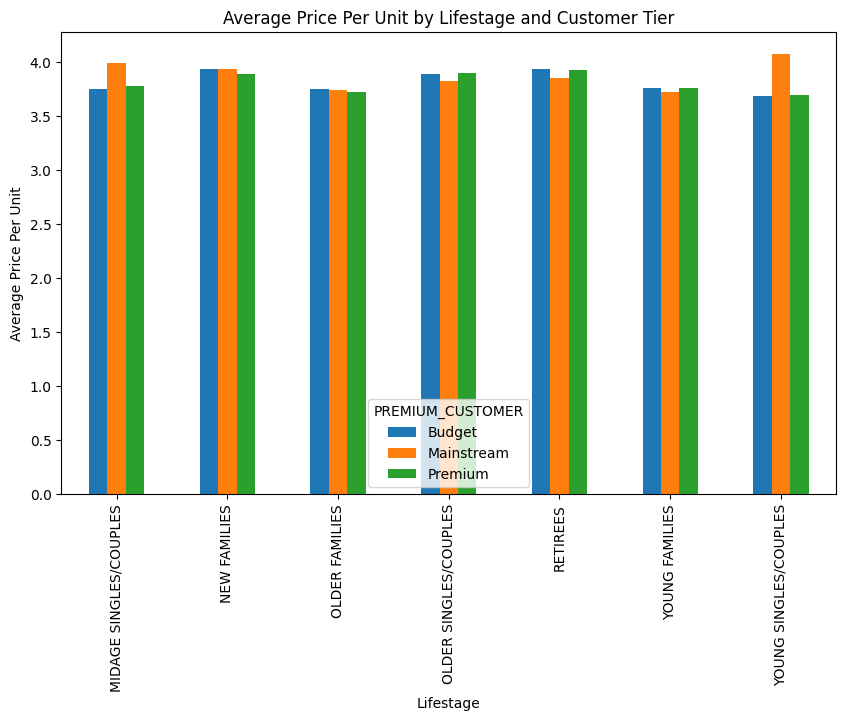

In [12]:
avg_qty.pivot(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', values='AVG_PRICE').plot(kind='bar', stacked=False, figsize=(10,6))
plt.title('Average Price Per Unit by Lifestage and Customer Tier')
plt.xlabel('Lifestage')
plt.ylabel('Average Price Per Unit')
avg_qty.to_csv('avg_price.csv', index=False)

In [11]:
#t test for sig diff between mainstream vs premium and budget midage and young single/couples
#avg_price column
df['PRICE_PER_UNIT'] = df['TOT_SALES'] / df['PROD_QTY']
#isolate groups
mainstream = df[(df['LIFESTAGE'].isin(['YOUNG SINGLES/COUPLES', 'MIDAGE SINGLES/COUPLES'])) & (df['PREMIUM_CUSTOMER'] == 'Mainstream')]['PRICE_PER_UNIT']
non_mainstream = df[(df['LIFESTAGE'].isin(['YOUNG SINGLES/COUPLES', 'MIDAGE SINGLES/COUPLES'])) & (df['PREMIUM_CUSTOMER'] != 'Mainstream')]['PRICE_PER_UNIT']
#run test
stat, p_value = ttest_ind(mainstream, non_mainstream)
print(f"P-Value: {p_value}")

P-Value: 2.235645611549444e-309


In [ ]:
#the unit price for mainstream young and midage singles and couples are signiticantly higher than that of budget or premium young and midage singles and couples

In [21]:
#want to test for brand preference in mainstream young/midage singles/couples
#affinity test setup
#target segment flag
target_segment = (df['LIFESTAGE'].isin(['YOUNG SINGLES/COUPLES', 'MIDAGE SINGLES/COUPLES'])) & (df['PREMIUM_CUSTOMER'] == 'Mainstream')

#group for brand proportions for target and non-target
brand_target = df[target_segment].groupby('BRAND')['PROD_QTY'].sum() / df[target_segment]['PROD_QTY'].sum()
brand_other = df[~target_segment].groupby('BRAND')['PROD_QTY'].sum() / df[~target_segment]['PROD_QTY'].sum()

#affinity index
brand_affinity = (brand_target / brand_other).sort_values(ascending=False)
print(brand_affinity)
#the young/midage singles and couples segments are 20.7% more likely to buy Twisities than other brands

BRAND
Twisties      1.207318
Kettle        1.193826
Tostitos      1.186656
Doritos       1.168535
Tyrrells      1.164316
Cobs          1.153728
Pringles      1.132796
Infuzions     1.119233
Grain         1.041311
Thins         1.038927
Cheezels      1.004214
Smiths        0.826045
Cheetos       0.724120
RRD           0.699227
Natural       0.688641
French        0.665766
CCs           0.647235
Woolworths    0.531750
Burger        0.513549
Sunbites      0.488305
Name: PROD_QTY, dtype: float64


In [22]:
#want to test for pack size tendencies in mainstream young/midage singles/couples
#affinity test setup

#group for pack size proportions for target and non-target
size_target = df[target_segment].groupby('PACK_SIZE')['PROD_QTY'].sum() / df[target_segment]['PROD_QTY'].sum()
size_other = df[~target_segment].groupby('PACK_SIZE')['PROD_QTY'].sum() / df[~target_segment]['PROD_QTY'].sum()

#affinity index
size_affinity = (size_target / size_other).sort_values(ascending=False)
print(size_affinity)
#the young/midage singles and couples segments are ~26.7% more likely to buy 270.0 g sized bags

PACK_SIZE
270.0    1.266827
330.0    1.222232
380.0    1.210029
110.0    1.174523
210.0    1.144747
134.0    1.132796
135.0    1.128870
250.0    1.091620
170.0    0.990036
150.0    0.969836
175.0    0.962681
165.0    0.898432
190.0    0.679711
180.0    0.621749
160.0    0.588499
70.0     0.559107
200.0    0.532535
220.0    0.513549
125.0    0.498462
90.0     0.488305
Name: PROD_QTY, dtype: float64
